# Novelty and Outlier Detection

Notebook ini membahas **novelty detection** dan **outlier detection** menggunakan scikit-learn. Fokus utama chapter ini adalah cara mendeteksi data yang menyimpang dari pola normal, baik data anomali yang sudah ada pada training set maupun data baru yang muncul saat prediksi.

Materi utama:
- Introduction to outlier and novelty detection
- Local Outlier Factor (LOF)
- Isolation Forest
- One-Class SVM
- Evaluating outlier detection models
- Handling detected outliers
- Choosing the right detection technique

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami perbedaan outlier detection dan novelty detection.
- Membuat dataset sintetis berisi data normal dan outlier.
- Menggunakan `LocalOutlierFactor` untuk deteksi outlier berbasis density.
- Menggunakan `IsolationForest` untuk mendeteksi anomali secara efisien.
- Menggunakan `OneClassSVM` untuk novelty detection ketika training data hanya berisi data normal.
- Mengevaluasi model deteksi anomali menggunakan confusion matrix, precision, recall, F1-score, dan ROC-AUC.
- Memahami pengaruh parameter `contamination`, `n_neighbors`, `nu`, dan `gamma`.
- Menentukan strategi penanganan outlier berdasarkan konteks masalah.
- Memilih teknik deteksi anomali yang sesuai berdasarkan struktur data.

## Persiapan Library

Cell berikut memuat library yang digunakan. Warning diabaikan agar output notebook tetap bersih.

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_classification
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_curve
)

np.random.seed(2024)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Model machine learning sangat bergantung pada kualitas data. Jika data training berisi data yang tidak representatif, noise ekstrem, atau bahkan data yang sengaja dimanipulasi, model dapat menghasilkan prediksi yang buruk. Karena itu, teknik deteksi anomali penting untuk menjaga robustness sistem machine learning.

Chapter ini membedakan dua konsep utama:

| Konsep | Penjelasan |
|---|---|
| Outlier Detection | Mendeteksi data menyimpang yang sudah ada dalam dataset training atau dataset analisis |
| Novelty Detection | Mendeteksi data baru yang belum pernah terlihat saat training dan menyimpang dari pola normal |
| Inlier | Data yang dianggap normal |
| Outlier/Novelty | Data yang dianggap tidak normal atau tidak sesuai pola umum |
| Contamination | Perkiraan proporsi outlier dalam dataset |

Metode utama yang dipelajari:

| Metode | Karakteristik |
|---|---|
| Isolation Forest | Mengisolasi anomali dengan random split |
| One-Class SVM | Mempelajari batas normalitas dari data normal saja |
| Local Outlier Factor | Membandingkan local density suatu titik dengan tetangganya |

## Introduction to Outlier and Novelty Detection

Outlier dan novelty sama-sama merujuk pada data yang berbeda dari pola umum. Namun, konteks penggunaannya berbeda.

**Outlier detection** digunakan ketika data anomali mungkin sudah ada pada dataset training. Model dilatih pada data yang mengandung campuran data normal dan outlier, lalu mencoba membedakan keduanya.

**Novelty detection** digunakan ketika data training diasumsikan hanya berisi data normal. Setelah model mempelajari pola normal, model digunakan untuk mendeteksi apakah data baru termasuk normal atau novelty.

Contoh aplikasi:
- Fraud detection
- Monitoring mesin industri
- Deteksi gangguan sensor
- Medical diagnostics
- Cybersecurity dan data poisoning detection
- Model monitoring untuk mendeteksi perubahan distribusi data

## Perbedaan Outlier dan Novelty

| Aspek | Outlier Detection | Novelty Detection |
|---|---|---|
| Data training | Bisa mengandung anomali | Umumnya hanya data normal |
| Tujuan | Menemukan anomali di dataset yang sedang dianalisis | Menandai data baru yang tidak sesuai pola normal |
| Contoh model | LOF, Isolation Forest | One-Class SVM, Isolation Forest |
| Waktu deteksi | Saat eksplorasi/training | Saat data baru masuk |
| Contoh kasus | Membersihkan dataset sebelum modeling | Monitoring transaksi baru |

Perbedaan ini penting karena strategi training dan evaluasinya berbeda. Jika training data sudah tercampur outlier, pendekatan outlier detection lebih sesuai. Jika training data bersih dan hanya berisi normal data, novelty detection lebih tepat.

## Membuat Dataset Sintetis dengan Outlier

Dataset sintetis dibuat menggunakan `make_blobs`. Data normal dibentuk sebagai satu cluster padat, kemudian outlier ditambahkan secara acak menggunakan distribusi uniform.

In [2]:
X_normal, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=0.60,
    random_state=2024
)

np.random.seed(2024)
X_outliers = np.random.uniform(low=-6, high=6, size=(20, 2))

X_with_outliers = np.vstack([X_normal, X_outliers])

y_true_outlier = np.array(
    [0] * len(X_normal) + [1] * len(X_outliers)
)  # 0 = inlier, 1 = outlier

print("Shape data normal:", X_normal.shape)
print("Shape outlier:", X_outliers.shape)
print("Shape gabungan:", X_with_outliers.shape)

Shape data normal: (300, 2)
Shape outlier: (20, 2)
Shape gabungan: (320, 2)


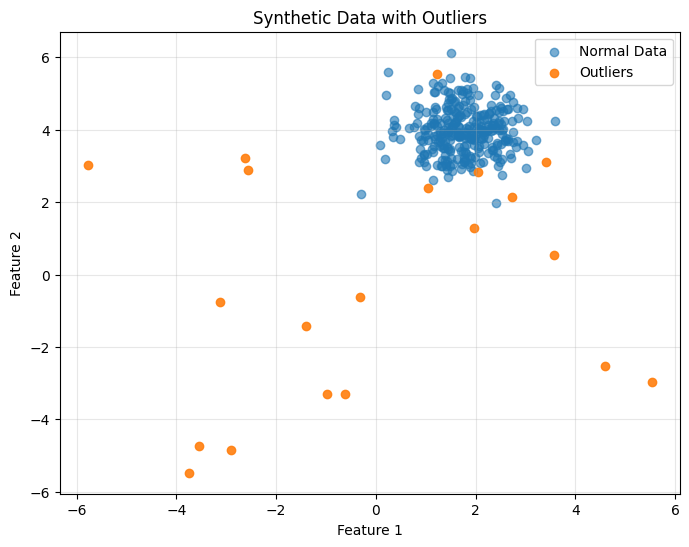

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], label="Normal Data", alpha=0.6)
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], label="Outliers", alpha=0.9)
plt.title("Synthetic Data with Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Analisis Dataset Sintetis

Visualisasi menunjukkan satu kelompok data normal yang padat dan beberapa titik yang menyebar jauh dari cluster utama. Titik-titik yang jauh ini mudah dianggap sebagai outlier secara visual.

Namun, pada data nyata, outlier tidak selalu terlihat jelas. Ada outlier yang berada dekat dengan data normal tetapi memiliki pola lokal yang tidak biasa. Karena itu, beberapa metode seperti LOF mengevaluasi kepadatan lokal, bukan hanya jarak global.

## Local Outlier Factor (LOF)

Local Outlier Factor atau LOF adalah metode deteksi anomali berbasis kepadatan lokal. LOF membandingkan density suatu titik dengan density tetangganya.

Jika suatu titik berada di area yang jauh lebih jarang dibandingkan tetangganya, maka titik tersebut dianggap lebih mencurigakan.

LOF cocok untuk:
- Dataset dengan density yang bervariasi.
- Deteksi outlier lokal.
- Situasi ketika outlier tidak selalu jauh secara global.
- Eksplorasi dataset training.

Catatan penting: LOF default di scikit-learn menggunakan `fit_predict()` untuk data training. Dalam mode default, LOF tidak digunakan untuk memprediksi data baru.

## Rumus K-Distance

Untuk suatu titik $p$, k-distance adalah jarak antara titik $p$ dan tetangga ke-$k$.

$$
k\text{-distance}(p) = d(p, o_k)
$$

Keterangan:

- $p$ = titik yang sedang dievaluasi
- $o_k$ = tetangga ke-$k$ dari titik $p$
- $d(p,o_k)$ = jarak antara $p$ dan tetangga ke-$k$

Nilai ini digunakan untuk menentukan neighborhood lokal suatu titik.

## Rumus Reachability Distance

Reachability distance digunakan untuk menstabilkan perhitungan jarak lokal.

$$
reach\_dist_k(p,o) = \max(k\text{-distance}(o), d(p,o))
$$

Keterangan:

- $p$ = titik yang sedang dievaluasi
- $o$ = salah satu tetangga dari $p$
- $k\text{-distance}(o)$ = jarak tetangga ke-$k$ dari titik $o$
- $d(p,o)$ = jarak aktual antara $p$ dan $o$

Reachability distance mencegah jarak yang terlalu kecil membuat density terlihat terlalu tinggi.

## Rumus Local Reachability Density

Local reachability density atau LRD mengukur seberapa padat neighborhood suatu titik.

$$
LRD_k(p)=
\left(
\frac{
\sum_{o \in N_k(p)} reach\_dist_k(p,o)
}{
|N_k(p)|
}
\right)^{-1}
$$

Keterangan:

- $LRD_k(p)$ = local reachability density titik $p$
- $N_k(p)$ = himpunan tetangga titik $p$
- $reach\_dist_k(p,o)$ = reachability distance antara $p$ dan tetangga $o$

Semakin besar LRD, semakin padat area sekitar titik tersebut.

## Rumus LOF Score

LOF membandingkan density tetangga terhadap density titik itu sendiri.

$$
LOF_k(p)=
\frac{
\sum_{o \in N_k(p)}
\frac{LRD_k(o)}{LRD_k(p)}
}{
|N_k(p)|
}
$$

Keterangan:

- $LOF_k(p)$ = skor LOF titik $p$
- $LRD_k(o)$ = density lokal tetangga
- $LRD_k(p)$ = density lokal titik yang dievaluasi

Interpretasi:
- Nilai mendekati 1: titik mirip dengan tetangganya.
- Nilai jauh lebih besar dari 1: titik cenderung outlier.

## Implementasi LOF pada Dataset Awal

Contoh berikut menggunakan `LocalOutlierFactor` dengan `n_neighbors=20` dan `contamination=0.05`.

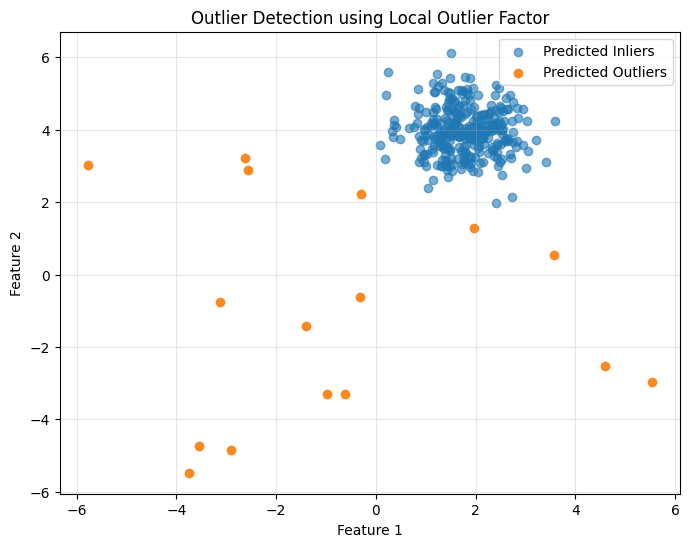

Jumlah outlier terdeteksi: 16


In [4]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

y_pred_lof_raw = lof.fit_predict(X_with_outliers)

# sklearn anomaly detector biasanya menghasilkan:
# 1 = inlier, -1 = outlier
y_pred_lof = np.where(y_pred_lof_raw == -1, 1, 0)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_with_outliers[y_pred_lof == 0, 0],
    X_with_outliers[y_pred_lof == 0, 1],
    label="Predicted Inliers",
    alpha=0.6
)
plt.scatter(
    X_with_outliers[y_pred_lof == 1, 0],
    X_with_outliers[y_pred_lof == 1, 1],
    label="Predicted Outliers",
    alpha=0.9
)
plt.title("Outlier Detection using Local Outlier Factor")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Jumlah outlier terdeteksi:", y_pred_lof.sum())

## Analisis LOF

LOF dapat mendeteksi titik yang berada pada area dengan density lebih rendah dibandingkan titik sekitarnya. Pada dataset sederhana, banyak outlier yang jauh dari cluster utama berhasil ditandai.

Parameter penting:
- `n_neighbors`: jumlah tetangga yang digunakan untuk menghitung density lokal.
- `contamination`: estimasi proporsi outlier.

Jika `n_neighbors` terlalu kecil, model bisa terlalu sensitif terhadap noise. Jika terlalu besar, model bisa melewatkan anomali lokal.

## Pengaruh n_neighbors pada LOF

Eksperimen berikut membandingkan hasil LOF dengan beberapa nilai `n_neighbors`.

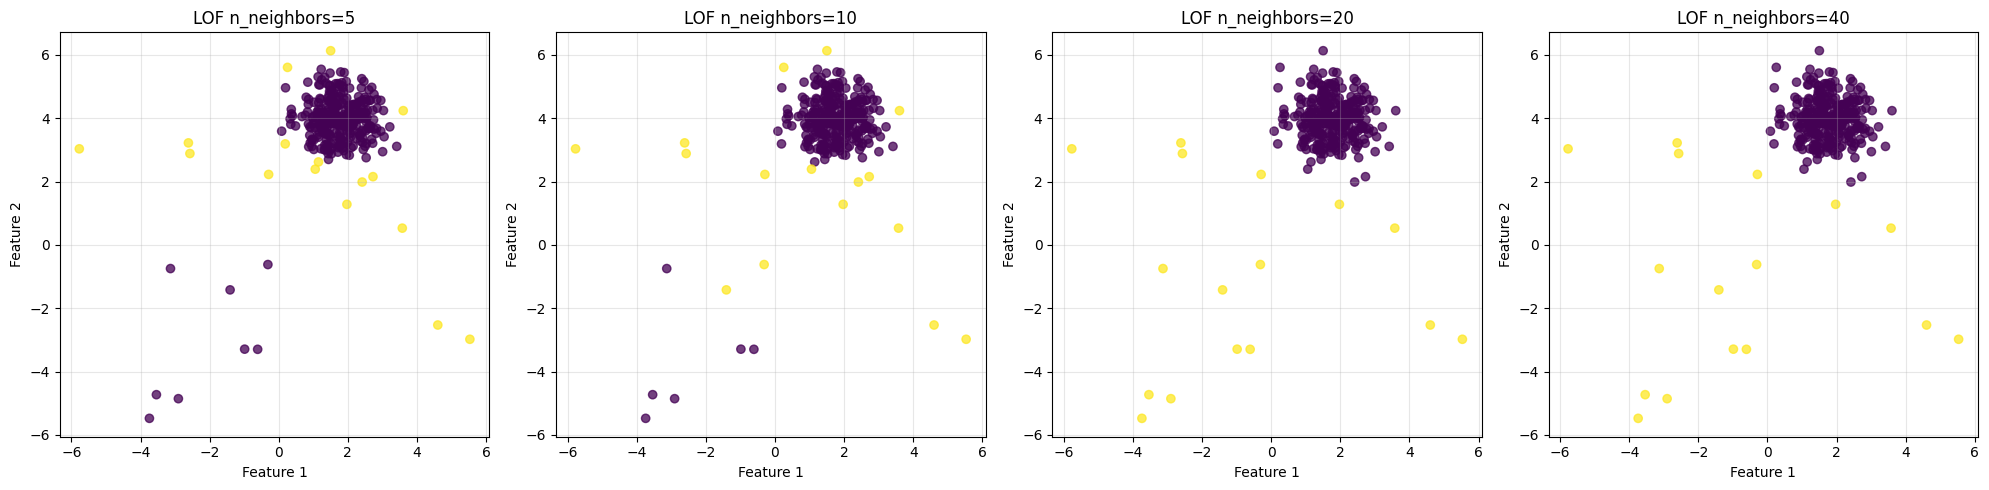

,n_neighbors,detected_outliers,precision,recall,f1_score
0,5,16,0.5625,0.45,0.500000
1,10,16,0.6875,0.55,0.611111
2,20,16,0.9375,0.75,0.833333
3,40,16,0.9375,0.75,0.833333


In [5]:
neighbor_values = [5, 10, 20, 40]

fig, axes = plt.subplots(1, len(neighbor_values), figsize=(20, 5))

lof_neighbor_results = []

for ax, n_neighbors in zip(axes, neighbor_values):
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=0.05
    )
    pred_raw = model.fit_predict(X_with_outliers)
    pred = np.where(pred_raw == -1, 1, 0)

    precision = precision_score(y_true_outlier, pred)
    recall = recall_score(y_true_outlier, pred)
    f1 = f1_score(y_true_outlier, pred)

    lof_neighbor_results.append({
        "n_neighbors": n_neighbors,
        "detected_outliers": pred.sum(),
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    })

    ax.scatter(X_with_outliers[:, 0], X_with_outliers[:, 1], c=pred, alpha=0.75)
    ax.set_title(f"LOF n_neighbors={n_neighbors}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

pd.DataFrame(lof_neighbor_results)

## Isolation Forest

Isolation Forest adalah algoritma yang mendeteksi anomali dengan cara mengisolasi data. Ide utamanya: data anomali biasanya lebih mudah diisolasi karena berbeda jauh dari mayoritas data.

Berbeda dari metode berbasis jarak atau density, Isolation Forest menggunakan random split pada fitur. Titik yang dapat diisolasi dengan sedikit split cenderung dianggap anomali.

Keunggulan Isolation Forest:
- Efisien untuk dataset besar.
- Cocok untuk data berdimensi tinggi.
- Dapat digunakan untuk outlier detection dan novelty detection.
- Tidak terlalu bergantung pada distance metric.

## Intuisi Matematis Isolation Forest

Isolation Forest menggunakan panjang jalur atau path length untuk mengukur seberapa cepat suatu titik terisolasi.

Jika $h(x)$ adalah path length titik $x$, maka anomaly score dapat ditulis secara konseptual sebagai:

$$
s(x,n)=2^{-\frac{E(h(x))}{c(n)}}
$$

Keterangan:

- $s(x,n)$ = anomaly score titik $x$
- $E(h(x))$ = rata-rata path length titik $x$ pada banyak tree
- $c(n)$ = rata-rata path length normalisasi untuk jumlah sampel $n$

Interpretasi:
- Jika path length pendek, $s(x,n)$ cenderung tinggi dan titik lebih mungkin anomali.
- Jika path length panjang, titik lebih mirip data normal.

## Implementasi Isolation Forest

Contoh berikut menggunakan `IsolationForest` dengan 100 estimator dan contamination 0.05.

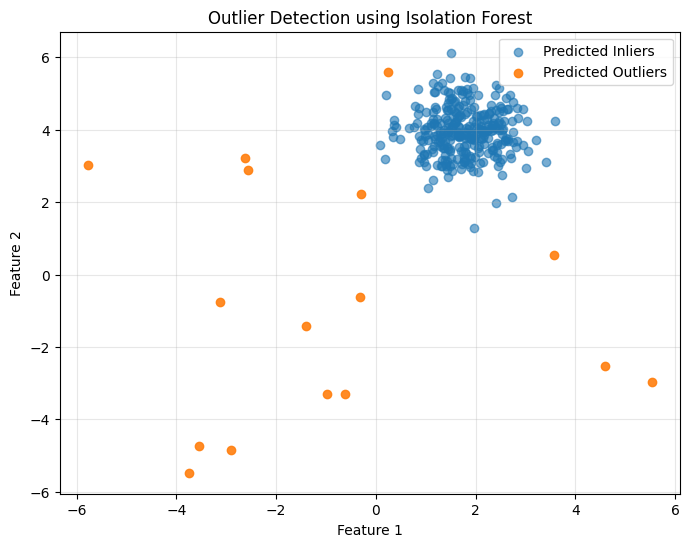

Jumlah outlier terdeteksi: 16


In [6]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=2024
)

iso_forest.fit(X_with_outliers)

y_pred_iso_raw = iso_forest.predict(X_with_outliers)
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_with_outliers[y_pred_iso == 0, 0],
    X_with_outliers[y_pred_iso == 0, 1],
    label="Predicted Inliers",
    alpha=0.6
)
plt.scatter(
    X_with_outliers[y_pred_iso == 1, 0],
    X_with_outliers[y_pred_iso == 1, 1],
    label="Predicted Outliers",
    alpha=0.9
)
plt.title("Outlier Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Jumlah outlier terdeteksi:", y_pred_iso.sum())

## Decision Function pada Isolation Forest

`decision_function()` menghasilkan skor kontinu. Nilai lebih rendah biasanya menunjukkan sampel lebih abnormal. Skor ini dapat digunakan untuk ranking anomali atau threshold tuning.

In [7]:
iso_scores = iso_forest.decision_function(X_with_outliers)

score_df = pd.DataFrame({
    "feature_1": X_with_outliers[:, 0],
    "feature_2": X_with_outliers[:, 1],
    "true_label": y_true_outlier,
    "predicted_outlier": y_pred_iso,
    "decision_score": iso_scores
}).sort_values("decision_score")

score_df.head(10)

,feature_1,feature_2,true_label,predicted_outlier,decision_score
311,5.530917,-2.978793,1,1,-0.193637
317,4.602464,-2.528626,1,1,-0.166503
305,-5.770717,3.031180,1,1,-0.166303
301,-3.742176,-5.474297,1,1,-0.157733
310,-2.904052,-4.853494,1,1,-0.139216
302,-3.539773,-4.727246,1,1,-0.136749
316,-3.132158,-0.747340,1,1,-0.109445
319,-0.986575,-3.290775,1,1,-0.101666
314,-1.407508,-1.420189,1,1,-0.101197
308,-0.610184,-3.295750,1,1,-0.099326


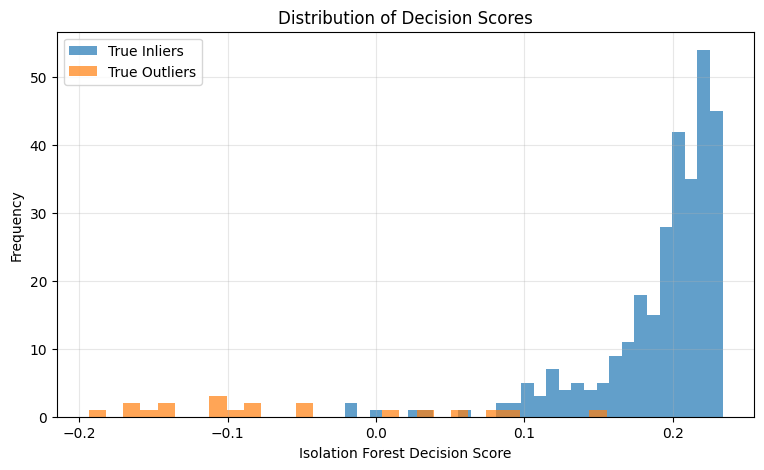

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(iso_scores[y_true_outlier == 0], bins=30, alpha=0.7, label="True Inliers")
plt.hist(iso_scores[y_true_outlier == 1], bins=30, alpha=0.7, label="True Outliers")
plt.xlabel("Isolation Forest Decision Score")
plt.ylabel("Frequency")
plt.title("Distribution of Decision Scores")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Pengaruh Contamination

Parameter `contamination` memperkirakan proporsi outlier dalam dataset. Nilai ini memengaruhi threshold keputusan.

Jika contamination terlalu kecil, model mungkin melewatkan banyak outlier. Jika terlalu besar, model bisa terlalu banyak menandai data normal sebagai outlier.

In [9]:
contamination_values = [0.02, 0.05, 0.10, 0.15]

contamination_results = []

for contamination in contamination_values:
    model = IsolationForest(
        contamination=contamination,
        random_state=2024,
        n_estimators=100
    )
    model.fit(X_with_outliers)
    pred_raw = model.predict(X_with_outliers)
    pred = np.where(pred_raw == -1, 1, 0)

    contamination_results.append({
        "contamination": contamination,
        "detected_outliers": pred.sum(),
        "precision": precision_score(y_true_outlier, pred),
        "recall": recall_score(y_true_outlier, pred),
        "f1_score": f1_score(y_true_outlier, pred)
    })

pd.DataFrame(contamination_results)

,contamination,detected_outliers,precision,recall,f1_score
0,0.02,7,1.000000,0.35,0.518519
1,0.05,16,0.875000,0.70,0.777778
2,0.10,32,0.593750,0.95,0.730769
3,0.15,48,0.395833,0.95,0.558824


## One-Class SVM untuk Novelty Detection

One-Class SVM digunakan ketika training data diasumsikan hanya berisi data normal. Model belajar batas normalitas, lalu data baru yang berada di luar batas tersebut dianggap novelty.

One-Class SVM cocok untuk:
- Fraud detection ketika contoh fraud sangat sedikit.
- Equipment failure prediction.
- Rare disease diagnostics.
- Monitoring data produksi.
- Situasi ketika data anomali tidak tersedia saat training.

Berbeda dengan outlier detection biasa, One-Class SVM sebaiknya dilatih hanya pada data normal.

## Rumus Hyperplane One-Class SVM

One-Class SVM mencoba memisahkan data normal dari origin pada ruang fitur hasil transformasi kernel.

Secara konseptual, fungsi keputusan dapat ditulis sebagai:

$$
f(x)=w^T\phi(x)-\rho
$$

Keterangan:

- $x$ = data input
- $\phi(x)$ = representasi data pada ruang fitur hasil kernel
- $w$ = vektor bobot
- $\rho$ = offset decision boundary

Jika $f(x) \ge 0$, data dianggap normal. Jika $f(x) < 0$, data dianggap novelty.

## Parameter Nu pada One-Class SVM

Parameter $\nu$ mengontrol trade-off antara false positive dan fleksibilitas boundary.

Secara intuitif:

$$
0 < \nu \le 1
$$

Keterangan:

- Nilai $\nu$ kecil membuat model lebih ketat.
- Nilai $\nu$ besar membuat boundary lebih fleksibel.
- $\nu$ juga dapat dipahami sebagai batas atas proporsi training error dan batas bawah proporsi support vectors.

Parameter lain yang penting adalah `gamma`, terutama jika menggunakan RBF kernel.

## Membuat Dataset Novelty Detection

Training data hanya berisi data normal. Test data berisi kombinasi data normal dan novelty.

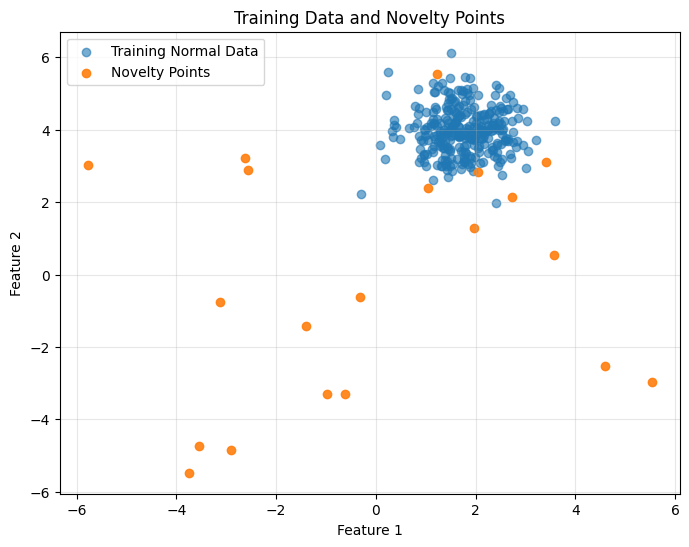

In [10]:
X_train_normal, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=0.6,
    random_state=2024
)

X_test_normal, _ = make_blobs(
    n_samples=100,
    centers=1,
    cluster_std=0.6,
    center_box=(0, 1),
    random_state=42
)

np.random.seed(2024)
X_test_novelty = np.random.uniform(low=-6, high=6, size=(20, 2))
X_test_novelty_all = np.vstack([X_test_normal, X_test_novelty])

y_test_novelty_true = np.array(
    [0] * len(X_test_normal) + [1] * len(X_test_novelty)
)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_normal[:, 0], X_train_normal[:, 1], label="Training Normal Data", alpha=0.6)
plt.scatter(X_test_novelty[:, 0], X_test_novelty[:, 1], label="Novelty Points", alpha=0.9)
plt.title("Training Data and Novelty Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Implementasi One-Class SVM

Model dilatih hanya pada data normal, lalu digunakan untuk memprediksi data test yang berisi normal dan novelty.

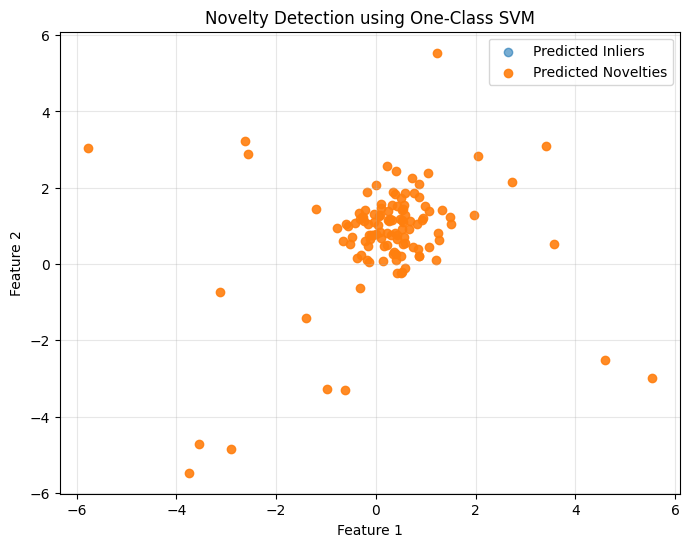

Novelty terdeteksi: 120


In [11]:
ocsvm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", OneClassSVM(kernel="rbf", gamma="scale", nu=0.05))
])

ocsvm_pipe.fit(X_train_normal)

y_pred_ocsvm_raw = ocsvm_pipe.predict(X_test_novelty_all)
y_pred_ocsvm = np.where(y_pred_ocsvm_raw == -1, 1, 0)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_test_novelty_all[y_pred_ocsvm == 0, 0],
    X_test_novelty_all[y_pred_ocsvm == 0, 1],
    label="Predicted Inliers",
    alpha=0.6
)
plt.scatter(
    X_test_novelty_all[y_pred_ocsvm == 1, 0],
    X_test_novelty_all[y_pred_ocsvm == 1, 1],
    label="Predicted Novelties",
    alpha=0.9
)
plt.title("Novelty Detection using One-Class SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Novelty terdeteksi:", y_pred_ocsvm.sum())

## Analisis One-Class SVM

One-Class SVM dapat membentuk boundary non-linear dengan kernel RBF. Namun, model ini sensitif terhadap scaling dan parameter seperti `nu` dan `gamma`.

Jika `gamma` terlalu besar, boundary menjadi terlalu detail dan bisa terlalu sensitif. Jika `gamma` terlalu kecil, boundary menjadi terlalu halus dan bisa gagal mendeteksi novelty.

## Pengaruh Nu dan Gamma pada One-Class SVM

Eksperimen berikut melihat kombinasi beberapa nilai `nu` dan `gamma`.

In [12]:
nu_values = [0.01, 0.05, 0.10]
gamma_values = ["scale", 0.1, 1.0]

ocsvm_results = []

for nu in nu_values:
    for gamma in gamma_values:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", OneClassSVM(kernel="rbf", gamma=gamma, nu=nu))
        ])
        model.fit(X_train_normal)
        pred_raw = model.predict(X_test_novelty_all)
        pred = np.where(pred_raw == -1, 1, 0)

        ocsvm_results.append({
            "nu": nu,
            "gamma": gamma,
            "detected_novelty": pred.sum(),
            "precision": precision_score(y_test_novelty_true, pred, zero_division=0),
            "recall": recall_score(y_test_novelty_true, pred, zero_division=0),
            "f1_score": f1_score(y_test_novelty_true, pred, zero_division=0)
        })

pd.DataFrame(ocsvm_results)

,nu,gamma,detected_novelty,precision,recall,f1_score
0,0.01,scale,118,0.152542,0.90,0.260870
1,0.01,0.1,108,0.148148,0.80,0.250000
2,0.01,1.0,120,0.166667,1.00,0.285714
3,0.05,scale,120,0.166667,1.00,0.285714
4,0.05,0.1,119,0.159664,0.95,0.273381
5,0.05,1.0,120,0.166667,1.00,0.285714
6,0.10,scale,120,0.166667,1.00,0.285714
7,0.10,0.1,120,0.166667,1.00,0.285714
8,0.10,1.0,120,0.166667,1.00,0.285714


## Detecting Outliers with LOF pada Density Berbeda

LOF sangat berguna ketika dataset memiliki cluster dengan density berbeda. Contoh berikut membuat dua cluster dengan standar deviasi berbeda, lalu menambahkan outlier.

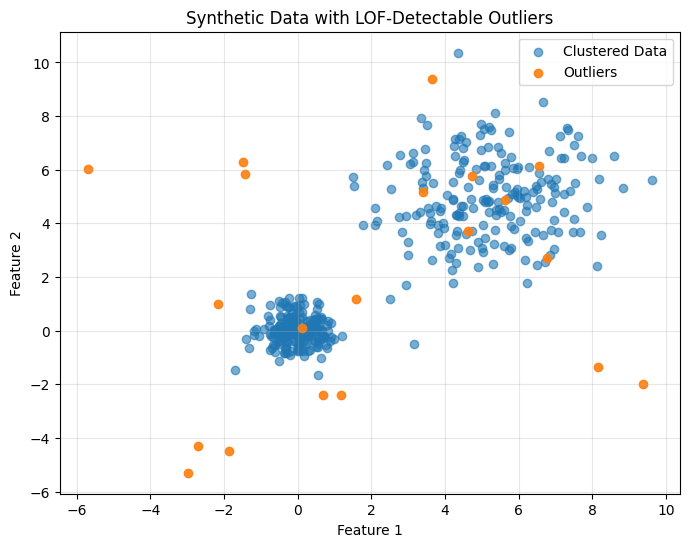

In [13]:
X_density, _ = make_blobs(
    n_samples=400,
    centers=[[0, 0], [5, 5]],
    cluster_std=[0.5, 1.5],
    random_state=2024
)

np.random.seed(2024)
X_density_outliers = np.random.uniform(low=-6, high=10, size=(20, 2))
X_density_combined = np.vstack([X_density, X_density_outliers])

y_density_true = np.array(
    [0] * len(X_density) + [1] * len(X_density_outliers)
)

plt.figure(figsize=(8, 6))
plt.scatter(X_density[:, 0], X_density[:, 1], label="Clustered Data", alpha=0.6)
plt.scatter(X_density_outliers[:, 0], X_density_outliers[:, 1], label="Outliers", alpha=0.9)
plt.title("Synthetic Data with LOF-Detectable Outliers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

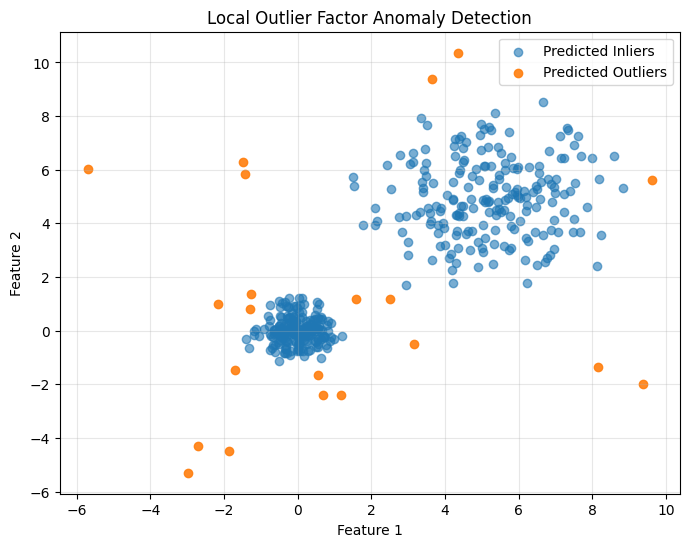

              precision    recall  f1-score   support

      Inlier       0.98      0.98      0.98       400
     Outlier       0.62      0.65      0.63        20

    accuracy                           0.96       420
   macro avg       0.80      0.81      0.81       420
weighted avg       0.97      0.96      0.96       420



In [14]:
lof_density = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

y_density_lof_raw = lof_density.fit_predict(X_density_combined)
y_density_lof = np.where(y_density_lof_raw == -1, 1, 0)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_density_combined[y_density_lof == 0, 0],
    X_density_combined[y_density_lof == 0, 1],
    label="Predicted Inliers",
    alpha=0.6
)
plt.scatter(
    X_density_combined[y_density_lof == 1, 0],
    X_density_combined[y_density_lof == 1, 1],
    label="Predicted Outliers",
    alpha=0.9
)
plt.title("Local Outlier Factor Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(classification_report(y_density_true, y_density_lof, target_names=["Inlier", "Outlier"]))

## Evaluating Outlier Detection Models

Evaluasi outlier detection lebih sulit dibanding supervised learning biasa karena:
- Outlier biasanya jarang.
- Label outlier sering tidak tersedia.
- Dataset biasanya imbalanced.
- Accuracy bisa menyesatkan.

Jika label tersedia, metrik yang bisa digunakan:
- Confusion matrix
- Precision
- Recall
- F1-score
- ROC-AUC

Pada deteksi anomali, recall penting jika tujuan utama adalah menemukan sebanyak mungkin anomali. Precision penting jika false alarm harus dikurangi.

## Rumus Confusion Matrix untuk Outlier Detection

Dalam outlier detection, outlier dapat dianggap sebagai kelas positif.

| Istilah | Makna |
|---|---|
| TP | Outlier benar terdeteksi sebagai outlier |
| TN | Inlier benar terdeteksi sebagai inlier |
| FP | Inlier salah ditandai sebagai outlier |
| FN | Outlier gagal terdeteksi |

Rumus metrik:

$$
Precision=\frac{TP}{TP+FP}
$$

$$
Recall=\frac{TP}{TP+FN}
$$

$$
F1=2\times\frac{Precision\times Recall}{Precision+Recall}
$$

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

## Dataset Berlabel untuk Evaluasi

Dataset berikut memiliki label ground truth: 0 untuk inlier dan 1 untuk outlier.

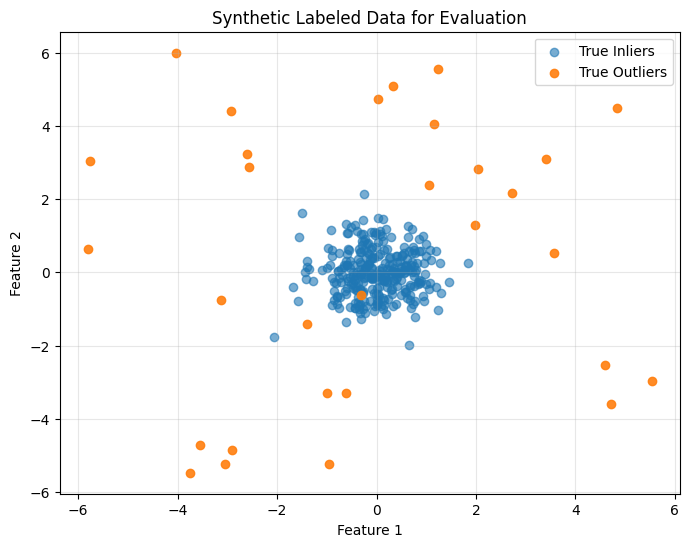

In [15]:
X_eval_inliers, _ = make_blobs(
    n_samples=300,
    centers=[[0, 0]],
    cluster_std=0.6,
    random_state=2024
)

np.random.seed(2024)
X_eval_outliers = np.random.uniform(low=-6, high=6, size=(30, 2))

X_eval = np.vstack([X_eval_inliers, X_eval_outliers])
y_eval_true = np.array([0] * len(X_eval_inliers) + [1] * len(X_eval_outliers))

plt.figure(figsize=(8, 6))
plt.scatter(X_eval[y_eval_true == 0, 0], X_eval[y_eval_true == 0, 1], label="True Inliers", alpha=0.6)
plt.scatter(X_eval[y_eval_true == 1, 0], X_eval[y_eval_true == 1, 1], label="True Outliers", alpha=0.9)
plt.title("Synthetic Labeled Data for Evaluation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Evaluasi Isolation Forest

Isolation Forest digunakan sebagai model evaluasi awal. Prediksi scikit-learn dikonversi dari format `1/-1` menjadi `0/1`.

In [16]:
eval_model = IsolationForest(
    contamination=0.09,
    random_state=2024,
    n_estimators=100
)

eval_model.fit(X_eval)

y_eval_pred_raw = eval_model.predict(X_eval)
y_eval_pred = np.where(y_eval_pred_raw == -1, 1, 0)

cm = confusion_matrix(y_eval_true, y_eval_pred)

cm_df = pd.DataFrame(
    cm,
    index=["True Inlier", "True Outlier"],
    columns=["Predicted Inlier", "Predicted Outlier"]
)

cm_df

,Predicted Inlier,Predicted Outlier
True Inlier,298,2
True Outlier,2,28


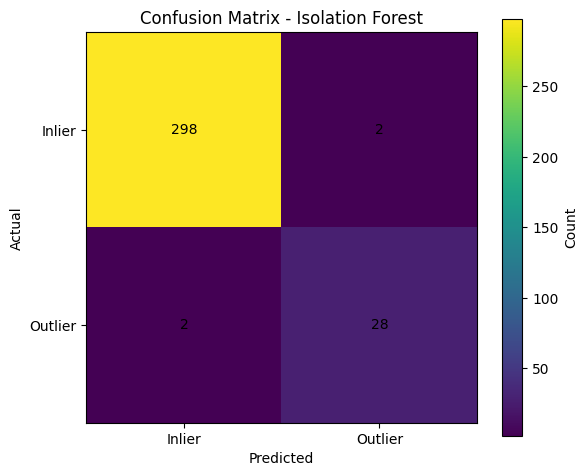

,precision,recall,f1-score,support
Inlier,0.993333,0.993333,0.993333,300.000000
Outlier,0.933333,0.933333,0.933333,30.000000
accuracy,0.987879,0.987879,0.987879,0.987879
macro avg,0.963333,0.963333,0.963333,330.000000
weighted avg,0.987879,0.987879,0.987879,330.000000


In [17]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Inlier", "Outlier"])
plt.yticks([0, 1], ["Inlier", "Outlier"])
plt.colorbar(label="Count")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

report_df = pd.DataFrame(
    classification_report(
        y_eval_true,
        y_eval_pred,
        target_names=["Inlier", "Outlier"],
        output_dict=True
    )
).transpose()

report_df

## ROC-AUC untuk Anomaly Score

ROC-AUC membutuhkan skor kontinu. Pada Isolation Forest, `decision_function()` menghasilkan skor normalitas. Karena skor lebih rendah berarti lebih anomalous, skor dibalik agar nilai lebih tinggi menunjukkan kemungkinan outlier.

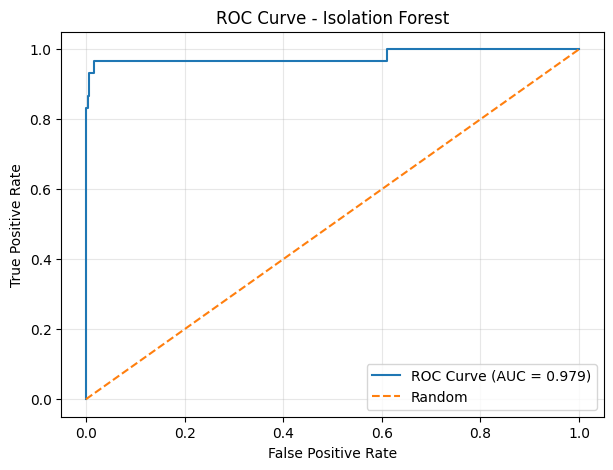

ROC-AUC: 0.9785555555555555


In [18]:
normality_score = eval_model.decision_function(X_eval)
anomaly_score = -normality_score

auc = roc_auc_score(y_eval_true, anomaly_score)

fpr, tpr, thresholds = roc_curve(y_eval_true, anomaly_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Isolation Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("ROC-AUC:", auc)

## Membandingkan Isolation Forest, LOF, dan One-Class SVM

Bagian ini membandingkan tiga metode pada dataset evaluasi yang sama.

In [19]:
models = {
    "Isolation Forest": IsolationForest(contamination=0.09, random_state=2024, n_estimators=100),
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=20, contamination=0.09),
    "One-Class SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", OneClassSVM(kernel="rbf", gamma="scale", nu=0.09))
    ])
}

comparison_results = []

# Isolation Forest
iso = models["Isolation Forest"]
iso.fit(X_eval)
pred_iso = np.where(iso.predict(X_eval) == -1, 1, 0)
comparison_results.append({
    "Model": "Isolation Forest",
    "Accuracy": accuracy_score(y_eval_true, pred_iso),
    "Precision": precision_score(y_eval_true, pred_iso),
    "Recall": recall_score(y_eval_true, pred_iso),
    "F1-score": f1_score(y_eval_true, pred_iso)
})

# LOF
lof_model = models["Local Outlier Factor"]
pred_lof = np.where(lof_model.fit_predict(X_eval) == -1, 1, 0)
comparison_results.append({
    "Model": "Local Outlier Factor",
    "Accuracy": accuracy_score(y_eval_true, pred_lof),
    "Precision": precision_score(y_eval_true, pred_lof),
    "Recall": recall_score(y_eval_true, pred_lof),
    "F1-score": f1_score(y_eval_true, pred_lof)
})

# One-Class SVM: untuk evaluasi sederhana di sini dilatih pada dataset campuran,
# tetapi untuk novelty detection yang benar sebaiknya dilatih hanya pada data normal.
oc = models["One-Class SVM"]
oc.fit(X_eval)
pred_oc = np.where(oc.predict(X_eval) == -1, 1, 0)
comparison_results.append({
    "Model": "One-Class SVM",
    "Accuracy": accuracy_score(y_eval_true, pred_oc),
    "Precision": precision_score(y_eval_true, pred_oc, zero_division=0),
    "Recall": recall_score(y_eval_true, pred_oc, zero_division=0),
    "F1-score": f1_score(y_eval_true, pred_oc, zero_division=0)
})

comparison_df = pd.DataFrame(comparison_results).sort_values("F1-score", ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Isolation Forest,0.987879,0.933333,0.933333,0.933333
1,Local Outlier Factor,0.987879,0.933333,0.933333,0.933333
2,One-Class SVM,0.939394,0.656250,0.700000,0.677419


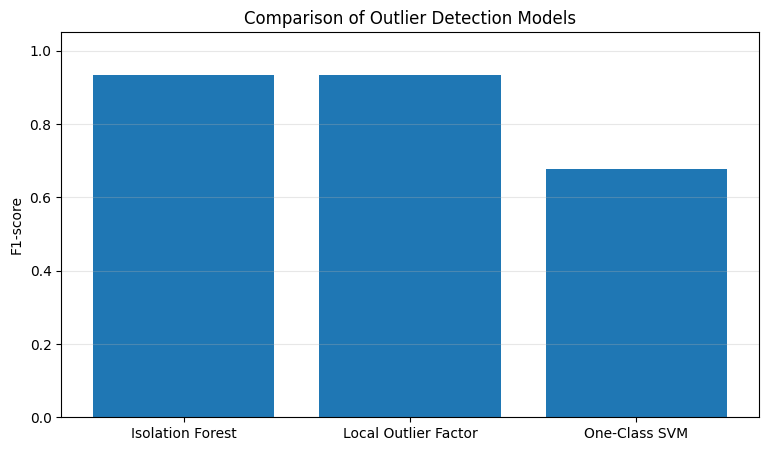

In [20]:
plt.figure(figsize=(9, 5))
plt.bar(comparison_df["Model"], comparison_df["F1-score"])
plt.ylabel("F1-score")
plt.title("Comparison of Outlier Detection Models")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Handling Detected Outliers

Setelah outlier terdeteksi, langkah selanjutnya tergantung konteks. Outlier tidak selalu harus dihapus. Ada outlier yang merupakan error data, tetapi ada juga outlier yang justru sangat penting.

Strategi umum:

| Strategi | Penjelasan | Contoh |
|---|---|---|
| Remove | Menghapus outlier dari training data | Sensor error, data input salah |
| Cap/Winsorize | Membatasi nilai ekstrem | Nilai transaksi terlalu besar akibat error |
| Transform | Menggunakan log transform atau scaling | Data skewed |
| Separate Model | Membuat model khusus untuk kasus anomali | Fraud detection |
| Flag Feature | Menambahkan kolom indikator outlier | Outlier tetap dipakai sebagai sinyal |
| Manual Review | Diverifikasi oleh manusia/domain expert | Medical, finance, cybersecurity |

Pada domain berisiko tinggi, outlier sebaiknya tidak langsung dihapus tanpa validasi.

## Contoh Handling Outlier: Remove vs Keep Flag

Contoh berikut membandingkan model supervised sederhana pada dataset klasifikasi yang diberi outlier/noise. Kita membandingkan:
1. Data asli.
2. Data setelah outlier dihapus.
3. Data dengan tambahan fitur flag outlier.

In [21]:
X_cls, y_cls = make_classification(
    n_samples=600,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    random_state=2024
)

# Tambahkan noise ekstrem pada sebagian sampel
rng = np.random.default_rng(2024)
n_noisy = 40
noisy_indices = rng.choice(np.arange(X_cls.shape[0]), size=n_noisy, replace=False)
X_cls_noisy = X_cls.copy()
X_cls_noisy[noisy_indices] += rng.normal(0, 8, size=X_cls_noisy[noisy_indices].shape)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls_noisy,
    y_cls,
    test_size=0.3,
    random_state=2024,
    stratify=y_cls
)

# Deteksi outlier pada training data
detector = IsolationForest(contamination=0.07, random_state=2024)
train_outlier_pred = np.where(detector.fit_predict(X_train_c) == -1, 1, 0)
test_outlier_pred = np.where(detector.predict(X_test_c) == -1, 1, 0)

# 1. Model baseline
baseline = RandomForestClassifier(random_state=2024)
baseline.fit(X_train_c, y_train_c)
baseline_pred = baseline.predict(X_test_c)

# 2. Remove outlier dari training
mask_inlier_train = train_outlier_pred == 0
removed_model = RandomForestClassifier(random_state=2024)
removed_model.fit(X_train_c[mask_inlier_train], y_train_c[mask_inlier_train])
removed_pred = removed_model.predict(X_test_c)

# 3. Tambahkan outlier flag sebagai fitur
X_train_flagged = np.column_stack([X_train_c, train_outlier_pred])
X_test_flagged = np.column_stack([X_test_c, test_outlier_pred])

flag_model = RandomForestClassifier(random_state=2024)
flag_model.fit(X_train_flagged, y_train_c)
flag_pred = flag_model.predict(X_test_flagged)

handling_results = pd.DataFrame([
    {
        "Strategy": "Keep Original Data",
        "Accuracy": accuracy_score(y_test_c, baseline_pred),
        "F1-score": f1_score(y_test_c, baseline_pred)
    },
    {
        "Strategy": "Remove Detected Outliers",
        "Accuracy": accuracy_score(y_test_c, removed_pred),
        "F1-score": f1_score(y_test_c, removed_pred)
    },
    {
        "Strategy": "Add Outlier Flag Feature",
        "Accuracy": accuracy_score(y_test_c, flag_pred),
        "F1-score": f1_score(y_test_c, flag_pred)
    }
])

handling_results

,Strategy,Accuracy,F1-score
0,Keep Original Data,0.905556,0.907104
1,Remove Detected Outliers,0.877778,0.877778
2,Add Outlier Flag Feature,0.888889,0.890110


## Analisis Handling Outlier

Hasil eksperimen dapat berbeda tergantung dataset. Menghapus outlier tidak selalu meningkatkan performa, karena beberapa outlier mungkin mengandung informasi penting. Menambahkan outlier flag dapat menjadi kompromi karena data tetap digunakan, tetapi model diberi informasi bahwa sampel tersebut mencurigakan.

Dalam praktik, keputusan handling outlier harus mempertimbangkan:
- Apakah outlier adalah error atau fenomena valid?
- Apakah outlier penting untuk kasus bisnis?
- Apakah model akan digunakan pada data produksi yang juga mengandung outlier?
- Apakah false positive atau false negative lebih mahal?

## Choosing the Right Detection Technique

Pemilihan teknik deteksi anomali bergantung pada karakteristik data dan tujuan analisis.

| Kondisi Data / Kebutuhan | Teknik yang Disarankan |
|---|---|
| Dataset besar dan high-dimensional | Isolation Forest |
| Training data hanya normal | One-Class SVM |
| Density lokal bervariasi | Local Outlier Factor |
| Butuh deteksi data baru | Isolation Forest atau One-Class SVM |
| Butuh deteksi lokal pada training set | LOF |
| Data sangat sensitif terhadap jarak | Gunakan scaling terlebih dahulu |
| Butuh interpretasi ranking anomali | Gunakan decision/anomaly score |

Tidak ada metode yang selalu terbaik. Model perlu dibandingkan berdasarkan data, label jika tersedia, dan konsekuensi kesalahan.

## Ringkasan Perbandingan Metode

| Metode | Kelebihan | Keterbatasan |
|---|---|---|
| Isolation Forest | Cepat, scalable, cocok high-dimensional, tidak berbasis jarak langsung | Perlu estimasi contamination |
| One-Class SVM | Baik untuk novelty detection, boundary non-linear | Sensitif scaling, mahal untuk dataset besar |
| LOF | Baik untuk local anomaly dan density bervariasi | Default tidak cocok untuk prediksi data baru |
| Rule-based | Mudah dijelaskan dan berbasis domain | Kurang fleksibel untuk pola kompleks |
| Supervised anomaly classifier | Bisa sangat akurat jika label tersedia | Membutuhkan label anomali yang cukup |

Praktik terbaik biasanya menggabungkan model statistik/ML dengan domain knowledge.

## Mini Studi Kasus: make_moons dengan Anomali

Dataset non-linear dibuat untuk melihat apakah metode berbasis density dan isolation dapat bekerja pada struktur data yang lebih kompleks.

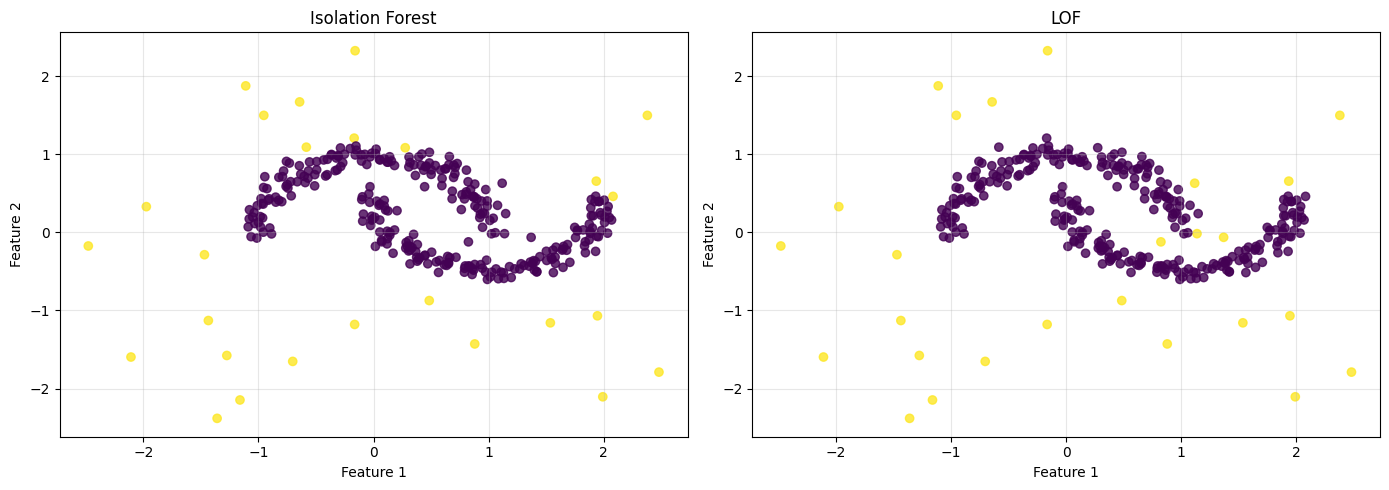

,Model,Precision,Recall,F1-score
0,Isolation Forest,0.807692,0.84,0.823529
1,LOF,0.846154,0.88,0.862745


In [22]:
X_moons, _ = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=2024
)

rng = np.random.default_rng(2024)
X_moons_outliers = rng.uniform(low=-2.5, high=2.5, size=(25, 2))
X_moons_combined = np.vstack([X_moons, X_moons_outliers])
y_moons_true = np.array([0] * len(X_moons) + [1] * len(X_moons_outliers))

moon_methods = {
    "Isolation Forest": IsolationForest(contamination=0.08, random_state=2024),
    "LOF": LocalOutlierFactor(n_neighbors=20, contamination=0.08)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

moon_results = []

for ax, (name, model) in zip(axes, moon_methods.items()):
    if name == "LOF":
        pred = np.where(model.fit_predict(X_moons_combined) == -1, 1, 0)
    else:
        model.fit(X_moons_combined)
        pred = np.where(model.predict(X_moons_combined) == -1, 1, 0)

    moon_results.append({
        "Model": name,
        "Precision": precision_score(y_moons_true, pred),
        "Recall": recall_score(y_moons_true, pred),
        "F1-score": f1_score(y_moons_true, pred)
    })

    ax.scatter(X_moons_combined[:, 0], X_moons_combined[:, 1], c=pred, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

pd.DataFrame(moon_results)

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Outlier | Data yang menyimpang dari pola umum dan bisa muncul pada training data |
| Novelty | Data baru yang tidak sesuai pola normal |
| Inlier | Data yang dianggap normal |
| Contamination | Estimasi proporsi anomali |
| LOF | Metode berbasis local density |
| Isolation Forest | Metode berbasis isolasi random split |
| One-Class SVM | Metode novelty detection berbasis boundary normalitas |
| Decision Function | Skor kontinu untuk ranking anomali |
| Precision | Ketepatan prediksi outlier |
| Recall | Kemampuan menemukan outlier aktual |
| F1-score | Keseimbangan precision dan recall |
| ROC-AUC | Kemampuan memisahkan outlier dan inlier menggunakan skor |
| Outlier Handling | Strategi setelah anomali terdeteksi |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa novelty dan outlier detection merupakan bagian penting dalam machine learning, terutama ketika data tidak selalu bersih atau representatif. Data anomali dapat menyebabkan model belajar pola yang salah, menghasilkan prediksi bias, atau gagal menghadapi data produksi.

Poin penting dari chapter ini:

- Outlier detection digunakan ketika anomali mungkin sudah ada dalam dataset.
- Novelty detection digunakan ketika model dilatih pada data normal dan diuji pada data baru.
- LOF mendeteksi outlier berdasarkan perbandingan density lokal.
- Isolation Forest mendeteksi anomali dengan mengisolasi titik menggunakan random split.
- One-Class SVM mempelajari boundary normalitas dan cocok untuk novelty detection.
- Parameter `contamination`, `n_neighbors`, `nu`, dan `gamma` sangat memengaruhi hasil deteksi.
- Evaluasi deteksi anomali sebaiknya menggunakan precision, recall, F1-score, confusion matrix, dan ROC-AUC jika label tersedia.
- Outlier tidak selalu harus dihapus; bisa juga diberi flag, ditransformasi, atau ditinjau secara manual.
- Pemilihan metode perlu mempertimbangkan struktur data, ukuran dataset, ketersediaan label, dan tujuan bisnis.

Secara keseluruhan, deteksi anomali bukan hanya proses teknis, tetapi juga keputusan analitis yang harus dikaitkan dengan konteks data dan risiko kesalahan.